This report has three parts:

1. **Paper-ready results** under Gaussian NPE, intended for the manuscript.
2. **Posterior sanity checks** against the reference posterior.
3. **Internal diagnostics** supporting the results above, not intended for the paper.

This report collects the paper's empirical results, re-run under Gaussian NPE and shown next to flow NPE. Section 1 is the submission-ready material that maps onto the manuscript's result slots; Sections 2 and 3 are supporting posterior checks and internal diagnostics, not intended for the paper. Read Section 1 as the main content.

## Internal note (remove before sending)

Status as of 2026-06-01. The sections are settled and the data is current. Before sending: delete this note and the Open-questions section at the end, and strip the inline TODO notes (the closing note lists the steps).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

DATA = Path("data")
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.5,
})
C_FLOW, C_GAUSS, C_REF = "#1f77b4", "#d62728", "#444444"
C_BSL = "#2ca02c"
BUDGETS = ["N=n", "N=n log(n)", "N=n^(3/2)", "N=n^2"]
BUDGET_MATH = ["n", r"n\log n", r"n^{3/2}", r"n^2"]
N_OBS = [100, 500, 1000, 5000]
METHOD_NAME = {"flow_npe": "flow-NPE", "gaussian_npe": "Gaussian-NPE"}
PARAM_MATH = {"A": "A", "B": "B", "g": "g", "k": "k",
              "lambda": r"\lambda", "sigma": r"\sigma", "xi": r"\xi"}
GNK_TRUE = {"A": 3.0, "B": 1.0, "g": 2.0, "k": 0.5}

# 1. Paper-ready results (Gaussian NPE)

The result slots already in the manuscript, presented under Gaussian NPE alongside flow NPE. This section is split to match the manuscript: **1A** collects the results that appear in the main body, and **1B** collects the results that appear in the appendices (the per-parameter coverage and bias breakdowns, the full KL grid, and the additional stereological parameters).

# 1A. Main-text results

These mirror the result slots in the manuscript's main body: g-and-k ($g$), MA(2) compatibility, and the stereological rate $\lambda$.

## 1A.1 g-and-k

Four parameters $(A, B, g, k)$ with octile summaries, so $d=11$. The reference is NUTS on the asymptotic summary-likelihood. The main text reports the bias and coverage for $g$ and the octile-vs-hexadecile KL comparison.

### Posterior-mean bias for $g$

Per-seed posterior-mean bias for $g$, flow and Gaussian side by side at each budget. The dashed line is zero bias.

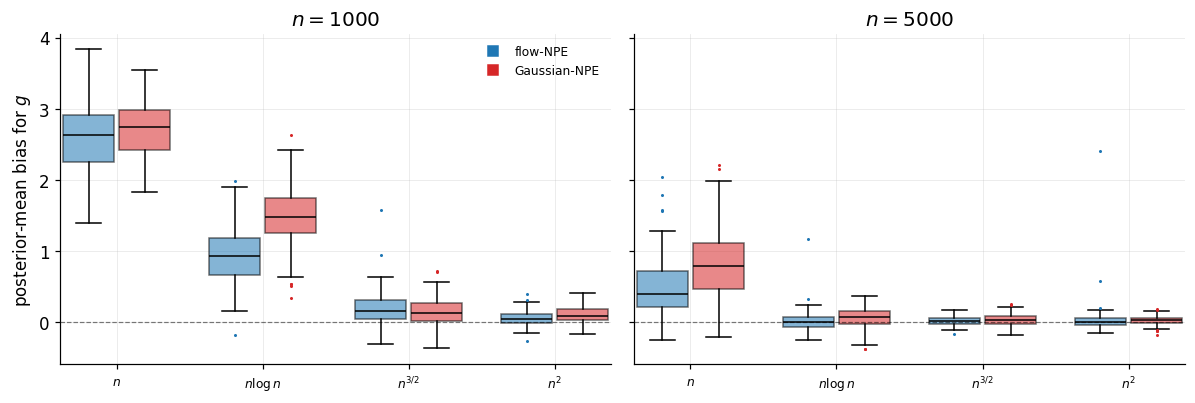

In [2]:
bias = pd.read_csv(DATA / "gnk_bias_g.csv")
bias = bias[bias.N_label.isin(BUDGETS)]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, n in zip(axes, [1000, 5000]):
    for b, bud in enumerate(BUDGETS):
        for k, (raw, color) in enumerate([("flow_npe", C_FLOW),
                                          ("gaussian_npe", C_GAUSS)]):
            vals = bias[(bias.n == n) & (bias.N_label == bud)
                        & (bias.method == raw)]["seed_mean_bias"].dropna().values
            if len(vals) == 0:
                continue
            bp = ax.boxplot([vals], positions=[b * 2.6 + k], widths=0.9,
                            patch_artist=True,
                            flierprops=dict(marker=".", markersize=2,
                                            markerfacecolor=color, markeredgecolor=color))
            for patch in bp["boxes"]:
                patch.set_facecolor(color)
                patch.set_alpha(0.55)
            for med in bp["medians"]:
                med.set_color("black")
    ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.5)
    ax.set_xticks([b * 2.6 + 0.5 for b in range(4)])
    ax.set_xticklabels([f"${b}$" for b in BUDGET_MATH], fontsize=8)
    ax.set_title(f"$n = {n}$")
axes[0].set_ylabel("posterior-mean bias for $g$")
axes[0].plot([], [], "s", color=C_FLOW, label="flow-NPE")
axes[0].plot([], [], "s", color=C_GAUSS, label="Gaussian-NPE")
axes[0].legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

### Coverage of credible intervals for $g$

Monte Carlo coverage of the 95% credible intervals for $g$ at $n=1000$, per budget. The intervals run at or above nominal here.

In [3]:
covg = pd.read_csv(DATA / "gnk_coverage_paper_grid.csv")
covg = covg[(covg.n == 1000) & (covg.param == "g")
            & covg.N_label.isin(BUDGETS)].copy()
covg["method"] = covg["method"].map(METHOD_NAME)
tab = covg.pivot_table(index=["method", "param"], columns="N_label",
                       values="coverage_95_mean")
tab = tab.reindex(columns=[b for b in BUDGETS if b in tab.columns]).round(3)
tab.columns.name = "budget (95% coverage, g)"
tab

,"budget (95% coverage, g)",N=n,N=n log(n),N=n^(3/2),N=n^2
method,param,,,,
Gaussian-NPE,g,1.0,1.0,0.997,0.985
flow-NPE,g,1.0,1.0,0.994,0.986


### KL: octiles vs hexadeciles

The same g-and-k inference with octile summaries ($d_s=7$, so $d=11$) and hexadecile summaries ($d_s=15$, so $d=19$). The higher-dimensional summary needs a larger budget for the same accuracy, the $d^2 n$ scaling showing up directly. The $n=100$ panel is the least trustworthy for Gaussian-NPE, since the reference posterior is far from Gaussian at $n=100$, so the $n=1000$ panel is the cleaner comparison.

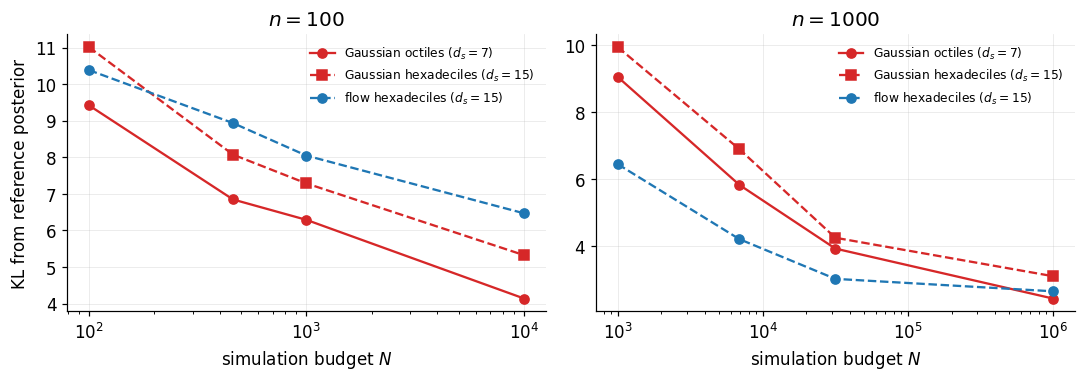

In [4]:
gnk = pd.read_csv(DATA / "gnk_kl_flow_vs_gaussian.csv")
oct_df = gnk[gnk.standard_paper_grid == 1].copy()
hex_g = pd.read_csv(DATA / "gnk_hexadecile_gaussian.csv")
hex_f = pd.read_csv(DATA / "gnk_hexadecile_flow.csv")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, n in zip(axes, [100, 1000]):
    o = oct_df[oct_df.n == n].sort_values("N")
    ax.plot(o.N, o.gaussian_theta_kl_median, "o-", color=C_GAUSS,
            label=r"Gaussian octiles ($d_s=7$)")
    h = hex_g[hex_g.n_obs == n].sort_values("n_sims")
    ax.plot(h.n_sims, h.finite_kl_median, "s--", color=C_GAUSS,
            label=r"Gaussian hexadeciles ($d_s=15$)")
    hf = hex_f[hex_f.n_obs == n]
    if "n_seeds" in hf.columns:
        hf = hf[hf.n_seeds >= 10]   # drop stray 1-2 seed budget cells
    hf = hf.sort_values("n_sims")
    if not hf.empty and "kl_median" in hf.columns:
        ax.plot(hf.n_sims, hf.kl_median, "o--", color=C_FLOW,
                label=r"flow hexadeciles ($d_s=15$)")
    ax.set_xscale("log")
    ax.legend(frameon=False, fontsize=8)
    ax.set_title(f"$n = {n}$")
    ax.set_xlabel("simulation budget $N$")
axes[0].set_ylabel("KL from reference posterior")
fig.tight_layout()
plt.show()

## 1A.2 MA(2)

Two parameters $(\theta_1, \theta_2)$ with the variance and first two autocovariances as summaries. The compatibility figure fixes $\delta_0(y)$ and varies the budget $N$.

### Compatibility: KL vs N

KL from the reference posterior to the NPE posterior at $n=1000$, for severe incompatibility ($\delta_0=0.01$) and mild incompatibility ($\delta_0=0.99$). Under severe incompatibility a larger budget does not help; under mild incompatibility the KL falls with the budget for both methods. This is the original two-panel result for the manuscript.

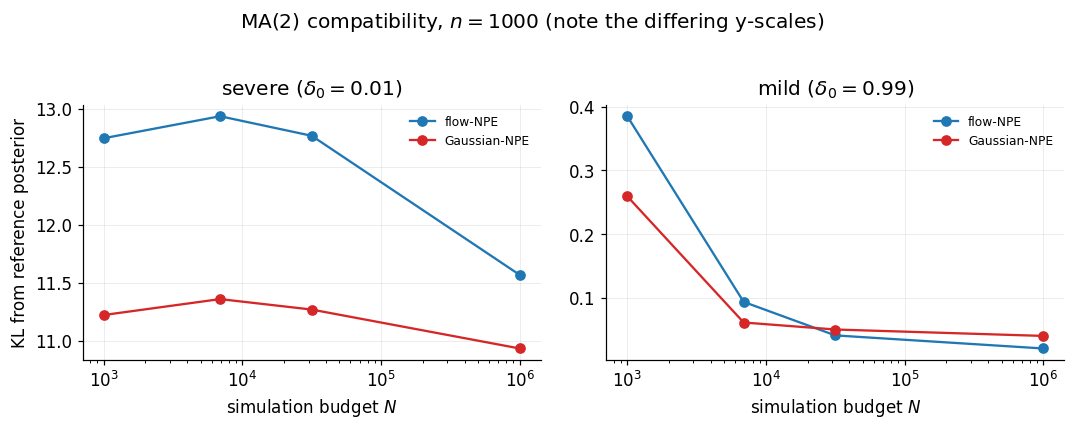

In [5]:
m = pd.read_csv(DATA / "ma2_three_case_kl.csv")
m = m[m.n_obs == 1000]
cases = [(0.01, "severe ($\\delta_0=0.01$)"),
         (0.99, "mild ($\\delta_0=0.99$)")]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, (d0, title) in zip(axes, cases):
    for raw, color in [("flow_npe", C_FLOW), ("gaussian_npe", C_GAUSS)]:
        s = m[(m.method == raw) & (m.delta0 == d0)].sort_values("n_sims")
        s = s[s.kl_median.notna() & (s.n_seeds > 0)]
        if not s.empty:
            ax.plot(s.n_sims, s.kl_median, "o-", color=color,
                    label=METHOD_NAME[raw])
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("simulation budget $N$")
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("KL from reference posterior")
fig.suptitle("MA(2) compatibility, $n=1000$ (note the differing y-scales)", y=1.02)
fig.tight_layout()
plt.show()

## 1A.3 Stereological

Three parameters $(\lambda, \sigma, \xi)$ and four summaries, so $d=7$. The reference is SMC-ABC. This is the paper's motivating example. The main text reports the rate $\lambda$.

### Coverage for $\lambda$

Monte Carlo coverage of the 95% credible intervals for $\lambda$, per budget and $n$. The $n=5000,\ N=n^2$ cell is not run (simulation cost).

In [6]:
cov = pd.read_csv(DATA / "stereological_coverage.csv")
cov = cov[(cov.N_label.isin(BUDGETS)) & (cov["param"] == "lambda")].copy()
cov["method"] = cov["method"].map(METHOD_NAME)
cov["N_label"] = pd.Categorical(cov["N_label"], categories=BUDGETS, ordered=True)
cov_table = cov.pivot_table(index=["method", "N_label"], columns="n",
                            values="coverage_95_mean", observed=True)
cov_table = cov_table.sort_index()[N_OBS].round(3)
cov_table = cov_table.where(cov_table.notna(), "")
cov_table.index.names = ["method", "budget"]
cov_table.columns.name = "n (95% coverage, lambda)"
cov_table

n (95% coverage, lambda)   100    500    1000   5000
method       budget                                 
Gaussian-NPE N=n          1.000  0.997  0.960  0.991
             N=n log(n)   0.975  0.925  0.942  0.966
             N=n^(3/2)    0.920  0.947  0.960  0.977
             N=n^2        0.963  0.968  0.969       
flow-NPE     N=n          1.000  1.000  1.000  0.999
             N=n log(n)   1.000  0.991  0.987  0.989
             N=n^(3/2)    0.991  0.972  0.976  0.974
             N=n^2        0.960  0.958  0.952

### Posterior-mean bias for $\lambda$

Per-seed posterior-mean bias for $\lambda$ by observation count, flow and Gaussian side by side at each budget.

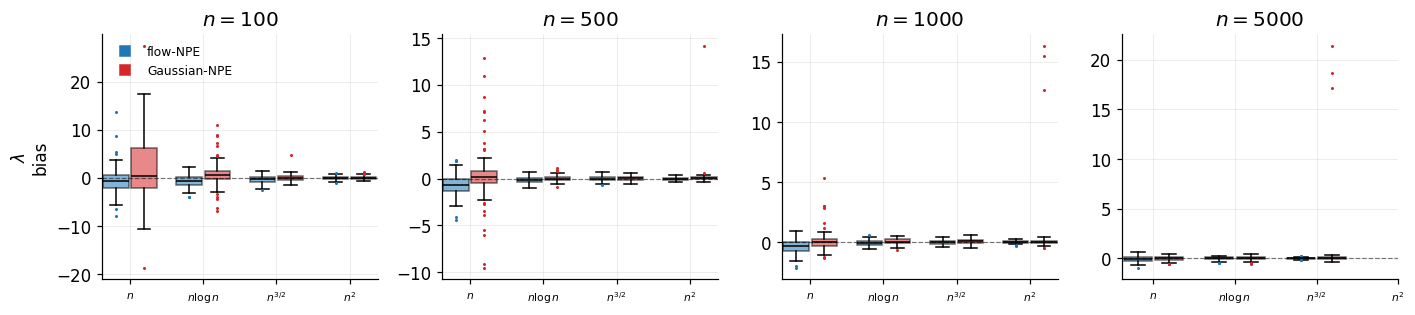

In [7]:
bias = pd.read_csv(DATA / "stereological_bias_by_seed.csv")
bias = bias[bias.N_label.isin(BUDGETS)]
params = ["lambda"]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.0), squeeze=False)
for r, param in enumerate(params):
    for c, n in enumerate(N_OBS):
        ax = axes[r, c]
        for b, bud in enumerate(BUDGETS):
            for k, (raw, color) in enumerate([("flow_npe", C_FLOW),
                                              ("gaussian_npe", C_GAUSS)]):
                vals = bias[(bias["param"] == param) & (bias.n == n)
                            & (bias.N_label == bud)
                            & (bias.method == raw)]["mean_bias"].dropna().values
                if len(vals) == 0:
                    continue
                bp = ax.boxplot([vals], positions=[b * 2.6 + k], widths=0.9,
                                patch_artist=True,
                                flierprops=dict(marker=".", markersize=2,
                                                markerfacecolor=color, markeredgecolor=color))
                for patch in bp["boxes"]:
                    patch.set_facecolor(color)
                    patch.set_alpha(0.55)
                for med in bp["medians"]:
                    med.set_color("black")
        ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.set_xticks([b * 2.6 + 0.5 for b in range(4)])
        ax.set_xticklabels([f"${b}$" for b in BUDGET_MATH], fontsize=7)
        ax.set_title(f"$n = {n}$")
        if c == 0:
            ax.set_ylabel(f"${PARAM_MATH[param]}$\nbias")
axes[0, 0].plot([], [], "s", color=C_FLOW, label="flow-NPE")
axes[0, 0].plot([], [], "s", color=C_GAUSS, label="Gaussian-NPE")
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

### Posterior for $\lambda$ vs ABC-SMC

Marginal posterior for $\lambda$ on a single simulated dataset ($n=1000$, seed 1), NPE at each budget against the SMC-ABC benchmark. The dashed line is the true $\lambda$.

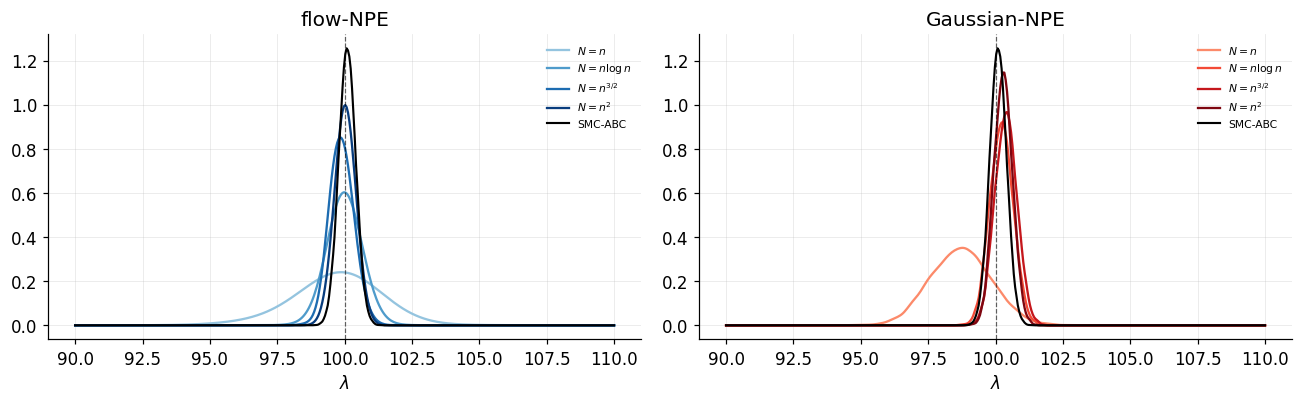

In [8]:
ster_ov = pd.read_csv(DATA / "stereological_posterior_overlay.csv")
lam = ster_ov[ster_ov.param == "lambda"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
specs = [("flow_npe", "flow-NPE", plt.cm.Blues),
         ("gaussian_npe", "Gaussian-NPE", plt.cm.Reds)]
for ax, (raw, mname, cmap) in zip(axes, specs):
    shades = cmap(np.linspace(0.4, 0.95, len(BUDGETS)))
    for bud, shade, lab in zip(BUDGETS, shades, BUDGET_MATH):
        s = lam[(lam.method == raw) & (lam.N_label == bud)].sort_values("x")
        if not s.empty:
            ax.plot(s.x, s.density, color=shade, label=f"$N={lab}$")
    a = lam[lam.method == "abc_smc"].sort_values("x")
    if not a.empty:
        ax.plot(a.x, a.density, color="black", lw=1.4, label="SMC-ABC")
    ax.axvline(100.0, color="black", ls="--", lw=0.8, alpha=0.6)
    ax.set_title(mname)
    ax.set_xlabel(r"$\lambda$")
    ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
plt.show()

# 1B. Appendix results

These mirror the manuscript's appendices: the full g-and-k KL grid and its remaining parameters ($A, B, k$), and the additional stereological parameters ($\sigma, \xi$). The MA(2) appendix in the paper is methodology only (KL estimation and exact partial-posterior sampling), so it carries no extra empirical panels here.

## 1B.1 g-and-k (appendix)

The full KL grid across all $n$ and budgets $N$, and coverage for the remaining parameters $A$, $B$, $k$. This is the report's version of the paper's appendix KL table.

### KL divergence, full $n$ by $N$ grid

Median over seeds of the KL from the reference posterior to the NPE posterior (flow / Gaussian), at each $n$ and budget $N$. The last row, the moment-matched Gaussian, is a reference floor: it is the KL you get if you replace the NPE with the single Gaussian whose mean and covariance match the reference posterior exactly. No Gaussian-family approximation can beat it, so it marks how much of the remaining KL is the Gaussian-family limit rather than anything NPE can fix with a larger budget.

In [9]:
gnk = pd.read_csv(DATA / "gnk_kl_flow_vs_gaussian.csv")
grid = gnk[gnk.standard_paper_grid == 1].copy()

def kl_entry(r):
    return f"{r.flow_theta_kl_median:.2f} / {r.gaussian_theta_kl_median:.2f}"

grid["entry"] = grid.apply(kl_entry, axis=1)
kl_table = grid.pivot(index="N_label", columns="n", values="entry")
kl_table = kl_table.reindex(BUDGETS)[N_OBS]
oracle = pd.read_csv(DATA / "gnk_theta_oracle_by_n.csv").set_index("n")
floor_col = "K_theta_star_median" if "K_theta_star_median" in oracle.columns else oracle.columns[-1]
kl_table.loc["moment-matched Gaussian"] = [
    f"{oracle.loc[n, floor_col]:.4f}" for n in N_OBS]
kl_table.index.name = "budget / floor (flow / Gaussian)"
kl_table.columns.name = "n"
kl_table

n,100,500,1000,5000
budget / floor (flow / Gaussian),,,,
N=n,9.83 / 9.42,9.02 / 8.28,8.88 / 9.05,6.87 / 7.69
N=n log(n),8.19 / 6.85,6.44 / 7.18,5.65 / 5.83,4.09 / 4.51
N=n^(3/2),6.86 / 6.29,4.41 / 4.51,3.63 / 3.94,2.59 / 2.98
N=n^2,4.31 / 4.14,2.07 / 2.83,1.82 / 2.45,2.22 / 2.67
moment-matched Gaussian,0.6698,0.0995,0.0487,0.0055


At each fixed $n$ the KL falls as the budget $N$ grows, and flow and Gaussian stay close to each other (Gaussian is modestly worse at the larger budgets, for example $2.67$ vs $2.22$ at $n=5000,\ N=n^2$, but not by a wide margin). One cell runs against the expected pattern: at the largest budget $N=n^2$ the median KL is lowest at $n=1000$ and then rises at $n=5000$ (flow $1.82 \to 2.22$, Gaussian $2.45 \to 2.67$), rather than continuing to fall with $n$. The paper's appendix text states the KL decreases in both $n$ and $N$, so this $n=5000,\ N=n^2$ cell is the one place that does not yet support that reading. It needs follow-up before the table goes in: see the Open-questions section.

The KL also does not fall to zero. The moment-matched-Gaussian floor is small (well under 1 at the larger $n$), so most of the remaining KL sits above that floor. Calling that gap finite-$N$ amortisation error is plausible but not yet established here; quantifying it is on the Open-questions list.

### Coverage of credible intervals for $A$, $B$, $k$

Monte Carlo coverage of the 95% credible intervals at $n=1000$, per parameter and budget. As with $g$ in the main text, these run at or above nominal (for example $k$ near 1.0).

In [10]:
covg = pd.read_csv(DATA / "gnk_coverage_paper_grid.csv")
covg = covg[(covg.n == 1000) & covg.param.isin(["A", "B", "k"])
            & covg.N_label.isin(BUDGETS)].copy()
covg["method"] = covg["method"].map(METHOD_NAME)
tab = covg.pivot_table(index=["method", "param"], columns="N_label",
                       values="coverage_95_mean")
tab = tab.reindex(columns=[b for b in BUDGETS if b in tab.columns]).round(3)
tab.columns.name = "budget (95% coverage)"
tab

budget (95% coverage)    N=n  N=n log(n)  N=n^(3/2)  N=n^2
method       param                                        
Gaussian-NPE A         0.992       0.934      0.934  0.955
             B         1.000       0.990      0.969  0.965
             k         0.993       1.000      1.000  0.991
flow-NPE     A         0.999       0.961      0.938  0.951
             B         0.999       0.997      0.985  0.963
             k         1.000       1.000      1.000  0.982

## 1B.2 Stereological (appendix): $\sigma$ and $\xi$

Coverage, posterior-mean bias, and posterior overlays for the shape and scale parameters $\sigma$ and $\xi$.

### Coverage for $\sigma$ and $\xi$

Monte Carlo coverage of the 95% credible intervals, per parameter, budget and $n$.

In [11]:
cov = pd.read_csv(DATA / "stereological_coverage.csv")
cov = cov[(cov.N_label.isin(BUDGETS)) & cov["param"].isin(["sigma", "xi"])].copy()
cov["method"] = cov["method"].map(METHOD_NAME)
cov["N_label"] = pd.Categorical(cov["N_label"], categories=BUDGETS, ordered=True)
cov_table = cov.pivot_table(index=["param", "method", "N_label"], columns="n",
                            values="coverage_95_mean", observed=True)
cov_table = cov_table.sort_index()[N_OBS].round(3)
cov_table = cov_table.where(cov_table.notna(), "")
cov_table.index.names = ["param", "method", "budget"]
cov_table.columns.name = "n (95% coverage)"
cov_table

n (95% coverage)                100    500    1000   5000
param method       budget                                
sigma Gaussian-NPE N=n         1.000  1.000  1.000    1.0
                   N=n log(n)  1.000  1.000  1.000    1.0
                   N=n^(3/2)   1.000  1.000  1.000  0.998
                   N=n^2       0.994  0.973  0.979       
      flow-NPE     N=n         1.000  1.000  1.000  0.997
                   N=n log(n)  1.000  0.992  0.995  0.993
                   N=n^(3/2)   1.000  0.991  0.980  0.961
                   N=n^2       0.992  0.963  0.969       
xi    Gaussian-NPE N=n         0.989  1.000  1.000    1.0
                   N=n log(n)  1.000  1.000  1.000    1.0
                   N=n^(3/2)   1.000  1.000  1.000    1.0
                   N=n^2       1.000  0.982  1.000       
      flow-NPE     N=n         0.788  0.958  0.991    1.0
                   N=n log(n)  0.952  0.995  1.000  0.993
                   N=n^(3/2)   0.984  0.996  0.991  0.985
                   N=n^2       0.998  0.975  0.974

### Posterior-mean bias for $\sigma$ and $\xi$

Per-seed posterior-mean bias by parameter and observation count, flow and Gaussian side by side at each budget.

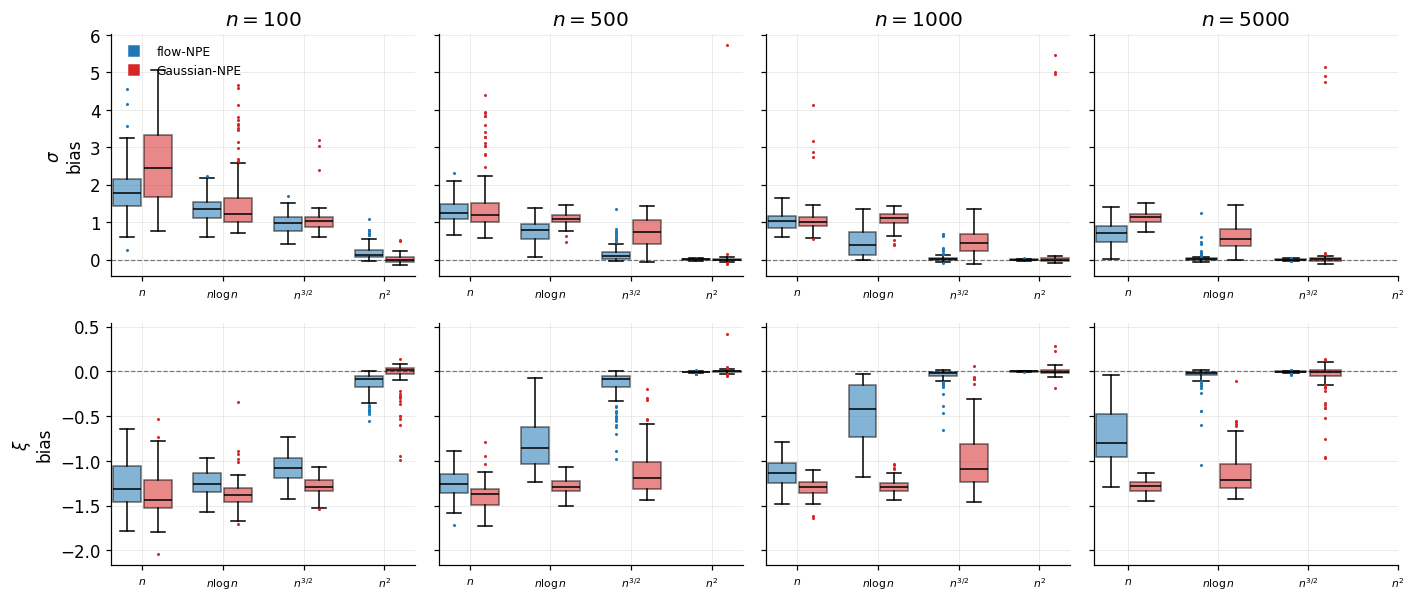

In [12]:
bias = pd.read_csv(DATA / "stereological_bias_by_seed.csv")
bias = bias[bias.N_label.isin(BUDGETS)]
params = ["sigma", "xi"]
# sharey='row' puts each parameter on one common scale across n, so the
# effect of increasing n is read directly.
fig, axes = plt.subplots(2, 4, figsize=(13, 5.6), squeeze=False, sharey="row")
for r, param in enumerate(params):
    for c, n in enumerate(N_OBS):
        ax = axes[r, c]
        for b, bud in enumerate(BUDGETS):
            for k, (raw, color) in enumerate([("flow_npe", C_FLOW),
                                              ("gaussian_npe", C_GAUSS)]):
                vals = bias[(bias["param"] == param) & (bias.n == n)
                            & (bias.N_label == bud)
                            & (bias.method == raw)]["mean_bias"].dropna().values
                if len(vals) == 0:
                    continue
                bp = ax.boxplot([vals], positions=[b * 2.6 + k], widths=0.9,
                                patch_artist=True,
                                flierprops=dict(marker=".", markersize=2,
                                                markerfacecolor=color, markeredgecolor=color))
                for patch in bp["boxes"]:
                    patch.set_facecolor(color)
                    patch.set_alpha(0.55)
                for med in bp["medians"]:
                    med.set_color("black")
        ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.set_xticks([b * 2.6 + 0.5 for b in range(4)])
        ax.set_xticklabels([f"${b}$" for b in BUDGET_MATH], fontsize=7)
        if r == 0:
            ax.set_title(f"$n = {n}$")
        if c == 0:
            ax.set_ylabel(f"${PARAM_MATH[param]}$\nbias")
axes[0, 0].plot([], [], "s", color=C_FLOW, label="flow-NPE")
axes[0, 0].plot([], [], "s", color=C_GAUSS, label="Gaussian-NPE")
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

### Posteriors for $\sigma$ and $\xi$ vs ABC-SMC

Marginal posteriors on a single simulated dataset ($n=1000$, seed 1), NPE at each budget against the SMC-ABC benchmark. Dashed lines are the true values ($\sigma=2.0$, $\xi=-0.1$).

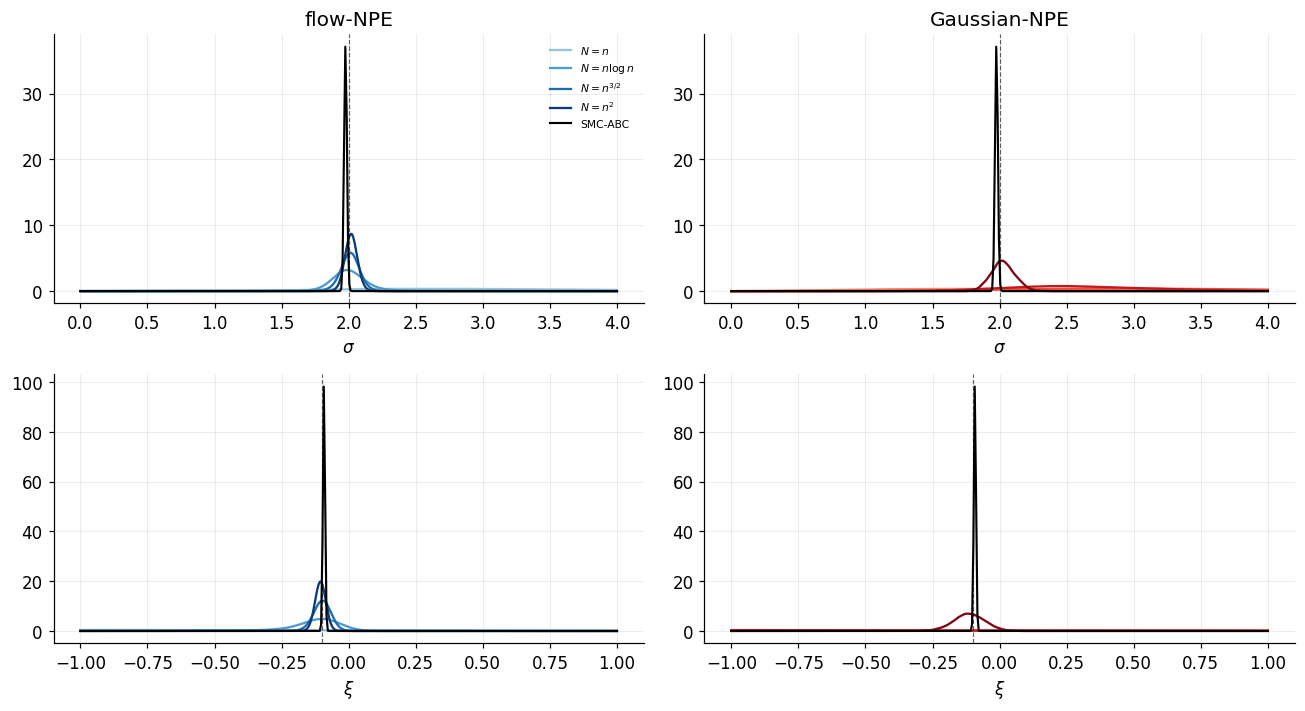

In [13]:
ster_ov = pd.read_csv(DATA / "stereological_posterior_overlay.csv")
truth = {"sigma": 2.0, "xi": -0.1}
specs = [("flow_npe", "flow-NPE", plt.cm.Blues),
         ("gaussian_npe", "Gaussian-NPE", plt.cm.Reds)]
params = ["sigma", "xi"]
fig, axes = plt.subplots(len(params), 2, figsize=(12, 6.6), squeeze=False)
for r, param in enumerate(params):
    d = ster_ov[ster_ov.param == param]
    for c, (raw, mname, cmap) in enumerate(specs):
        ax = axes[r, c]
        shades = cmap(np.linspace(0.4, 0.95, len(BUDGETS)))
        for bud, shade, lab in zip(BUDGETS, shades, BUDGET_MATH):
            s = d[(d.method == raw) & (d.N_label == bud)].sort_values("x")
            if not s.empty:
                ax.plot(s.x, s.density, color=shade, label=f"$N={lab}$")
        a = d[d.method == "abc_smc"].sort_values("x")
        if not a.empty:
            ax.plot(a.x, a.density, color="black", lw=1.4, label="SMC-ABC")
        ax.axvline(truth[param], color="black", ls="--", lw=0.8, alpha=0.6)
        if r == 0:
            ax.set_title(mname)
        ax.set_xlabel(f"${PARAM_MATH[param]}$")
        if r == 0 and c == 0:
            ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
plt.show()

# 2. Posterior sanity checks

Plain posterior overlays: Gaussian NPE and flow NPE against the reference posterior, to confirm by eye that the approximations are reasonable. Not intended for the paper.

## 2.1 Posterior overlays vs reference

### g-and-k

Marginal posteriors for the four parameters at two headline cells, reference against the two NPE variants.

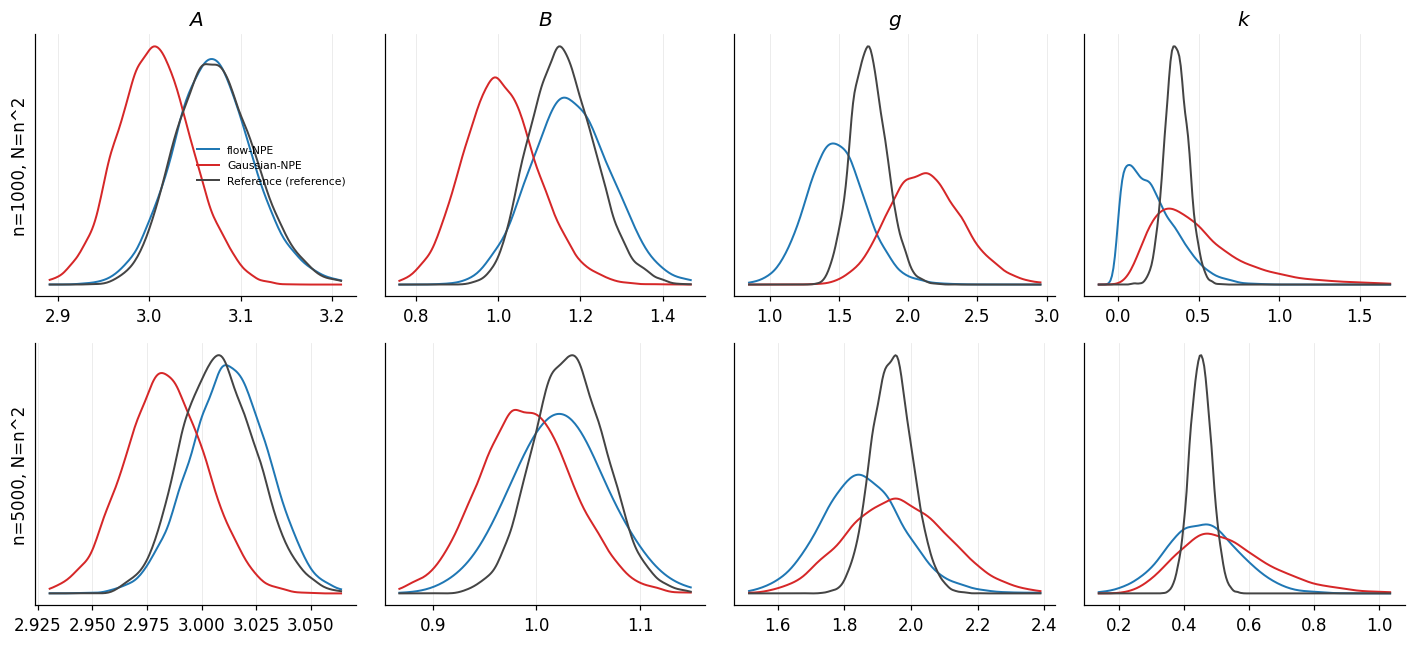

In [14]:
ov = pd.read_csv(DATA / "gnk_posterior_overlay.csv")
cells_to_show = ["n=1000, N=n^2", "n=5000, N=n^2"]
fig, axes = plt.subplots(len(cells_to_show), 4, figsize=(13, 6))
for r, cell in enumerate(cells_to_show):
    sub = ov[ov.cell == cell]
    for c, param in enumerate(["A", "B", "g", "k"]):
        ax = axes[r, c]
        d = sub[sub.param == param]
        for method, color in [("flow-NPE", C_FLOW),
                              ("Gaussian-NPE", C_GAUSS),
                              ("Reference (flow convention)", C_REF)]:
            dd = d[d.method == method].sort_values("x")
            if not dd.empty:
                ax.plot(dd.x, dd.density, color=color, lw=1.3,
                        label=method.replace(" (flow convention)", " (reference)"))
        if r == 0 and c == 0:
            ax.legend(frameon=False, fontsize=7)
        if r == 0:
            ax.set_title(f"${param}$")
        ax.set_yticks([])
    axes[r, 0].set_ylabel(cell)
fig.tight_layout()
plt.show()

### MA(2)

Joint posterior for $(\theta_1, \theta_2)$ at a representative seed (seed 22, $n=1000$, $N=n^2$), flow and Gaussian against the true posterior.

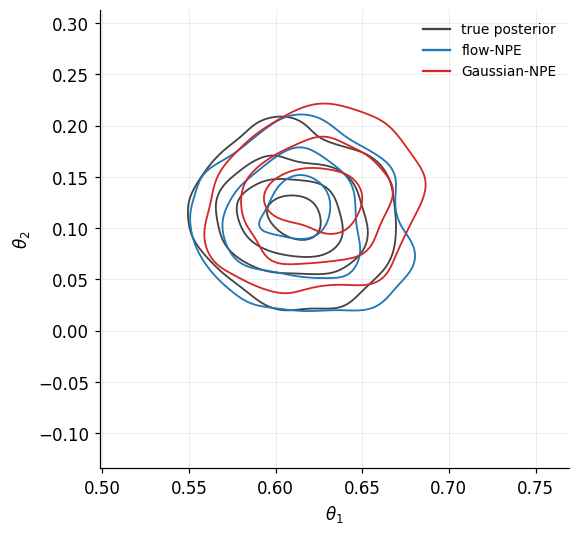

In [15]:
from scipy.stats import gaussian_kde
ma2 = pd.read_csv(DATA / "ma2_posterior_overlay_seed_22.csv")
fig, ax = plt.subplots(figsize=(5.4, 5.0))
xg = np.linspace(ma2.t1.min(), ma2.t1.max(), 140)
yg = np.linspace(ma2.t2.min(), ma2.t2.max(), 140)
XX, YY = np.meshgrid(xg, yg)
grid = np.vstack([XX.ravel(), YY.ravel()])
for method, color in [("true posterior", C_REF),
                      ("flow-NPE", C_FLOW),
                      ("Gaussian-NPE", C_GAUSS)]:
    s = ma2[ma2.method == method]
    if len(s) < 20:
        continue
    ZZ = gaussian_kde(np.vstack([s.t1, s.t2]))(grid).reshape(XX.shape)
    ax.contour(XX, YY, ZZ, levels=4, colors=[color], linewidths=1.2)
    ax.plot([], [], color=color, label=method)
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

### Stereological

Marginal posteriors for $(\lambda, \sigma, \xi)$ at the largest available budget, NPE variants against SMC-ABC ($n=1000$, seed 1).

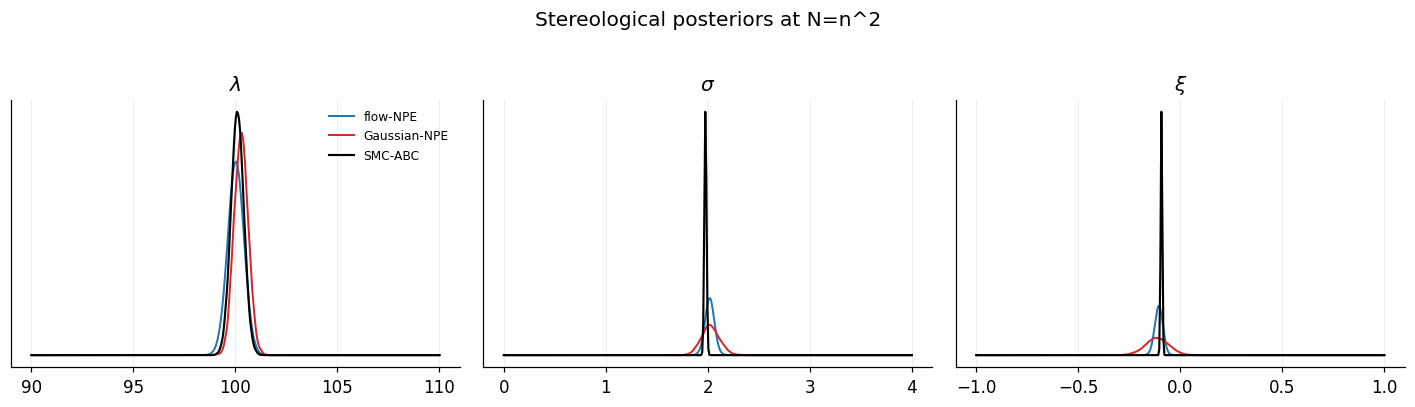

In [16]:
ster_ov = pd.read_csv(DATA / "stereological_posterior_overlay.csv")
budget_order = [b for b in BUDGETS if b in set(ster_ov.N_label.dropna())]
top_budget = budget_order[-1] if budget_order else None
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, param in zip(axes, ["lambda", "sigma", "xi"]):
    d = ster_ov[ster_ov.param == param]
    for raw, color, lab in [("flow_npe", C_FLOW, "flow-NPE"),
                            ("gaussian_npe", C_GAUSS, "Gaussian-NPE")]:
        s = d[(d.method == raw) & (d.N_label == top_budget)].sort_values("x")
        if not s.empty:
            ax.plot(s.x, s.density, color=color, lw=1.3, label=lab)
    a = d[d.method == "abc_smc"].sort_values("x")
    if not a.empty:
        ax.plot(a.x, a.density, color="black", lw=1.4, label="SMC-ABC")
    ax.set_title(f"${PARAM_MATH[param]}$")
    ax.set_yticks([])
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"Stereological posteriors at {top_budget}", y=1.02)
fig.tight_layout()
plt.show()

## 2.2 g-and-k BSL sanity check

Bayesian synthetic likelihood (BSL) as an independent check on the g-and-k reference, requested by Chris. This is a single-cell check at $n=1000$, seed 0, not a full-grid result. At that cell BSL recovers the NUTS reference closely, which supports reading the NPE gap as an NPE-side effect rather than a problem with the reference.

Direct posterior overlay: BSL against the NUTS reference, per parameter. Close agreement supports the reference.

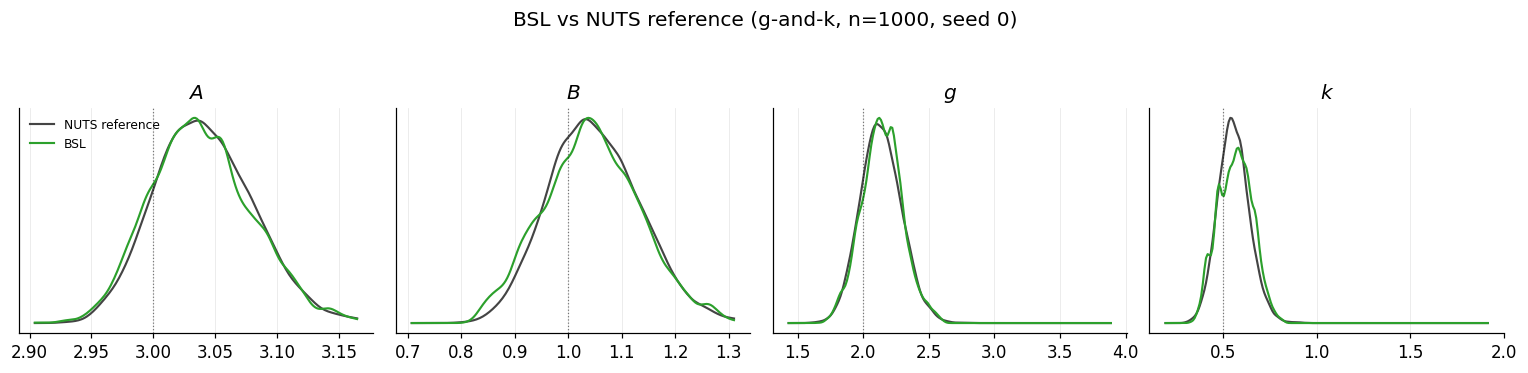

In [17]:
ov = pd.read_csv(DATA / "gnk_robust_scaling_overlay.csv")
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for c, param in enumerate(["A", "B", "g", "k"]):
    ax = axes[c]
    d = ov[ov.param == param]
    for method, color, lab in [("NUTS reference", C_REF, "NUTS reference"),
                               ("BSL", C_BSL, "BSL")]:
        s = d[d.method == method].sort_values("x")
        if not s.empty:
            ax.plot(s.x, s.density, color=color, lw=1.4, label=lab)
    ax.axvline(GNK_TRUE[param], color="black", ls=":", lw=0.8, alpha=0.5)
    ax.set_title(f"${param}$")
    ax.set_yticks([])
    if c == 0:
        ax.legend(frameon=False, fontsize=8)
fig.suptitle("BSL vs NUTS reference (g-and-k, n=1000, seed 0)", y=1.05)
fig.tight_layout()
plt.show()

# 3. Internal diagnostics

Supporting checks, not for the paper. Each answers a specific question about whether the Section 1 results are sound. Kept short, with the reason stated up front.

## 3.1 Posterior Gaussianity and the small-n regime

Why this matters: the theory assumes a near-Gaussian (Bernstein-von Mises) posterior. To check this we take the g-and-k reference posterior and compute the KL to its own best-fitting Gaussian (matched mean and covariance). Zero means the reference is exactly Gaussian; larger means further from Gaussian. The figure shows this by $n$: small at the larger $n$ used in the headline results, much larger at $n=100$, which is the regime where the near-Gaussian assumption breaks down (and where Gaussian-NPE should not be expected to do well).

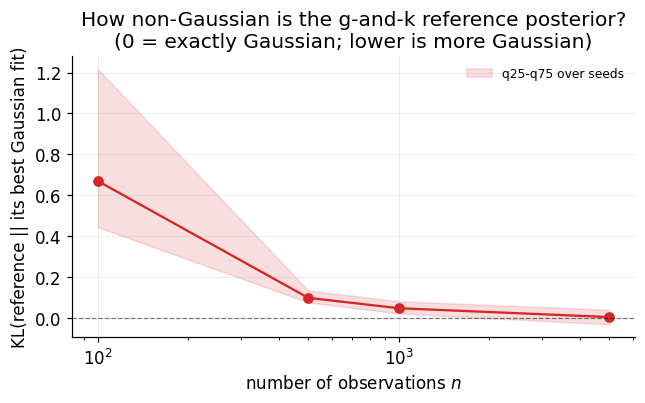

In [18]:
oracle = pd.read_csv(DATA / "gnk_theta_oracle_by_n.csv").sort_values("n")
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(oracle.n, oracle.K_theta_star_median, "o-", color=C_GAUSS)
if {"K_theta_star_q25", "K_theta_star_q75"} <= set(oracle.columns):
    ax.fill_between(oracle.n, oracle.K_theta_star_q25, oracle.K_theta_star_q75,
                    color=C_GAUSS, alpha=0.15, label="q25-q75 over seeds")
    ax.legend(frameon=False, fontsize=8)
ax.set_xscale("log")
ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.5)
ax.set_xlabel("number of observations $n$")
ax.set_ylabel("KL(reference || its best Gaussian fit)")
ax.set_title("How non-Gaussian is the g-and-k reference posterior?\n"
             "(0 = exactly Gaussian; lower is more Gaussian)")
fig.tight_layout()
plt.show()

## 3.2 NPE does not fully recover the g-and-k reference

Why this matters: if NPE cannot recover the g-and-k posterior even at the largest budget, that would weaken the g-and-k support for the theory. The point of this section is to see how large the gap is and where it comes from.

At $n=1000$, seed 0 the NPE posterior does not sit exactly on the reference; the gap is mostly on $g$ and $k$. This is not specific to the Gaussian family. The flow variant in Section 2.1 misses in much the same way, so it is a property of NPE here, not of the Gaussian approximation. BSL recovers the reference closely (Section 2.2), so the reference itself is not in doubt.

Two things change the match, both recorded as context only and neither a paper result:

- Standardisation. The prior-predictive octile summaries span many orders of magnitude, so plain per-coordinate z-scoring compresses the informative region. Robust (asinh / median-IQR) standardisation improves the match and does not change the method or the theory's assumptions, so it is an admissible default. It would mean re-running the whole grid, so it is not a change to make lightly.
- Rejection-ABC trimming. This also improves the match, but only by discarding simulations, which is preconditioning and does not match the theory's assumptions. Shown for contrast, not as a fix.

The overlay below makes this easier to read than the KL numbers: it shows the reference, the two standardisations, rejection-ABC and BSL on the same axes, per parameter.

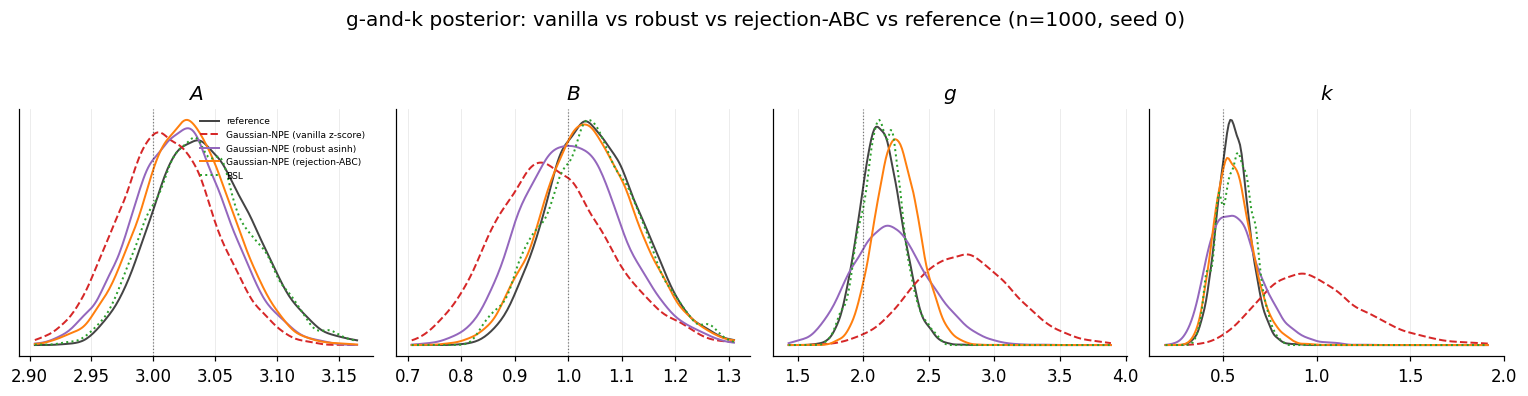

In [19]:
ov = pd.read_csv(DATA / "gnk_improvement_overlay.csv")
methods = [
    ("NUTS reference", C_REF, "-", "reference"),
    ("Gaussian-NPE (z-score)", C_GAUSS, "--", "Gaussian-NPE (vanilla z-score)"),
    ("Gaussian-NPE (robust asinh)", "#9467bd", "-", "Gaussian-NPE (robust asinh)"),
    ("Gaussian-NPE (rejection-ABC)", "#ff7f0e", "-", "Gaussian-NPE (rejection-ABC)"),
    ("BSL", C_BSL, ":", "BSL"),
]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for c, param in enumerate(["A", "B", "g", "k"]):
    ax = axes[c]
    d = ov[ov.param == param]
    for method, color, ls, lab in methods:
        s = d[d.method == method].sort_values("x")
        if not s.empty:
            ax.plot(s.x, s.density, color=color, ls=ls, lw=1.3, label=lab)
    ax.axvline(GNK_TRUE[param], color="black", ls=":", lw=0.8, alpha=0.5)
    ax.set_title(f"${param}$")
    ax.set_yticks([])
    if c == 0:
        ax.legend(frameon=False, fontsize=6)
fig.suptitle("g-and-k posterior: vanilla vs robust vs rejection-ABC vs "
             "reference (n=1000, seed 0)", y=1.05)
fig.tight_layout()
plt.show()

The same comparison as KL from the reference:

In [20]:
rej = json.loads((DATA / "gnk_rejection_abc_summary.json").read_text())
rows = [
    ("vanilla z-score Gaussian-NPE", rej.get("vanilla_canonical_kl")),
    ("robust asinh Gaussian-NPE", rej.get("robust_canonical_kl")),
    ("rejection-ABC Gaussian-NPE", rej.get("kl_reference_to_npe_value")),
    ("BSL (reference cross-check)", rej.get("bsl_unique_kl")),
]
summary = pd.DataFrame(
    [(name, round(v, 3)) for name, v in rows if v is not None],
    columns=["method (g-and-k, n=1000, seed 0)", "KL(reference || .)"])
display(summary)

,"method (g-and-k, n=1000, seed 0)",KL(reference || .)
0,vanilla z-score Gaussian-NPE,4.705
1,robust asinh Gaussian-NPE,1.369
2,rejection-ABC Gaussian-NPE,0.810
3,BSL (reference cross-check),0.024


## 3.3 Dimension scaling (pilot, the most direct test of the theory)

This is the experiment that bears most directly on the central result. The theory says the budget must grow like $N \gtrsim d^2 n$ to control the KL from the reference. So if we hold $N/(d^2 n)$ fixed and vary the summary dimension $d_s$, the KL should stay roughly controlled rather than blow up. This pilot fixes $n=500$, holds $N/(d^2 n) = 5$, and ranges $d_s$ over $\{5,7,11,15,19\}$ (so $d = d_s + d_\theta$).

Read honestly, the pilot does not yet show what we want: the median KL rises with $d$ rather than staying flat. This is the opposite of the behaviour the theory predicts, so it is the result we most need to understand before leaning on it. Three things could drive the rise without contradicting the theory, and none is resolved here: the constant $5$ may be too small (the condition is asymptotic in $N$); $n=500$ may be too small, so the g-and-k posterior is still somewhat non-Gaussian at this $n$ (Section 3.1); and it is worth pinning down against the exact theorem statement how much of the rise in raw KL is expected from the theory's own $d$-dependence versus a genuine shortfall in the budget. The plan (see Open questions) is to rerun at $n=1000$, sweep the constant rather than fix it at $5$, and add the MA(2) compatible case as a cleaner near-Gaussian second example. Treat the figure below as a provisional pilot.

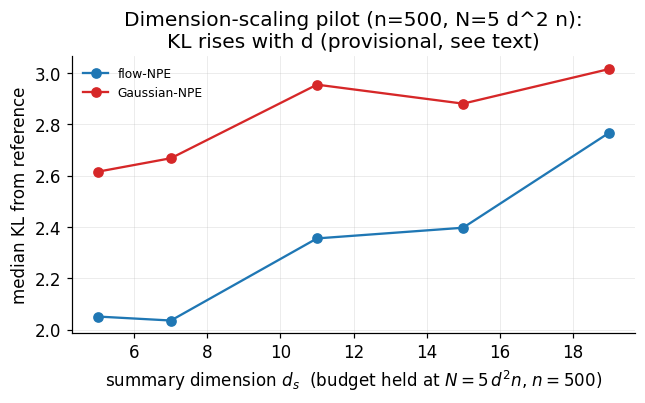

In [21]:
dim = pd.read_csv(DATA / "dim_scaling_pilot_kl_by_d.csv")
finite = dim[dim["theta_kl"].notna()] if "theta_kl" in dim.columns else dim
if "d_s" in finite.columns and "theta_kl" in finite.columns:
    g = (finite.groupby(["method", "d_s"])["theta_kl"]
               .median().reset_index())
    fig, ax = plt.subplots(figsize=(6, 3.8))
    for raw, color in [("flow_npe", C_FLOW), ("gaussian_npe", C_GAUSS)]:
        s = g[g.method == raw].sort_values("d_s")
        if not s.empty:
            ax.plot(s.d_s, s.theta_kl, "o-", color=color,
                    label=METHOD_NAME.get(raw, raw))
    ax.set_xlabel(r"summary dimension $d_s$  (budget held at $N=5\,d^2 n$, $n=500$)")
    ax.set_ylabel("median KL from reference")
    ax.set_title("Dimension-scaling pilot (n=500, N=5 d^2 n):\n"
                 "KL rises with d (provisional, see text)")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print("dim-scaling columns:", list(dim.columns))
    display(dim.head())

---

# Open questions and notes for discussion (internal, remove before sending)

Honest open items to take into the group meeting. Several need a rerun or extended reasoning, not a report edit, and are flagged as such.

**MA(2), well-specified case ($\delta_0=1$).** This was examined and the earlier discrepancy traced to a bug, since addressed. It connects to the point David Warne raised in the meeting and does not reflect any problem with the results in the published arXiv version. The well-specified panel is currently out of the report; whether it returns as an appendix baseline is a minor call.

**g-and-k KL at $n=5000,\ N=n^2$ (1B.1).** At the largest budget the median KL rises from $n=1000$ to $n=5000$ rather than falling, which runs against the theory and against the paper's appendix wording. Needs follow-up before the appendix table is final: this cell has 91 of 101 seeds and one unstable flow seed (KL ~24), so check whether the rise survives the full seed set, or whether it is a genuine effect to explain. (Rerun / data.)

**Oracle floor vs the residual KL (1B.1).** The moment-matched-Gaussian floor is low, so most of the remaining KL sits above it. Calling that gap finite-$N$ amortisation error is asserted, not shown. Worth quantifying, since a non-trivial unexplained gap is a sore point for the theory. (Analysis.)

**Stereological $\sigma$ and $\xi$ (1B.2).** NPE recovers the rate $\lambda$ well but does noticeably worse on $\sigma$ and $\xi$. The report should not look like it foregrounds $\lambda$ and buries the rest. Decide how to present $\sigma$ and $\xi$ honestly. (Framing.)

**Why NPE underperforms BSL on g-and-k (3.2).** First, confirm the gap is not large enough to weaken the g-and-k support for the theory. Second, a useful follow-up is to show that sequential NPE or preconditioned NPE (with SMC-ABC) recovers the reference here. That would locate the gap in the one-shot amortised NPE setup rather than in neural methods as a class, and move the discussion toward why NPE misses. A GPT-5.5 Pro literature brief on improving standardisation within the theory's assumptions also fits here. (Rerun + Pro.)

**Dimension scaling (3.3).** The most direct test, and it does not yet show the predicted flatness. Rerun at $n=1000$, sweep the constant in $N = c\,d^2 n$ rather than fixing $c=5$, and add the MA(2) compatible case as a near-Gaussian second example. Separately, pin down against the theorem whether the comparison should be on raw KL (my reading) or some normalised quantity. (Rerun + Pro / coauthors.)

**Posterior Gaussianity for the other examples (3.1).** The best-Gaussian-fit-by-$n$ check is only done for g-and-k. The same plot for the stereological and MA(2) references would show whether the near-Gaussian assumption holds there too. (Rerun.)

**Coverage audit.** Confirm every main-text and appendix result in the paper is represented here and matches, including the choice of median (this report) vs mean with standard deviation (paper appendix KL table). (Audit.)

---

> **TODO:** Before sending: delete the internal note at the top and the Open-questions section above, strip all TODO notes, and confirm code cells are hidden.